In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit

In [2]:
nu_true = 0.01 / np.pi

def exact_burgers(x, t, nu=nu_true):
    if t == 0:
        return -np.sin(np.pi * x)
    def integrand_num(eta):
        return np.sin(np.pi * eta) * \
               np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(x - eta)**2 / (4 * nu * t))
    def integrand_den(eta):
        return np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(x - eta)**2 / (4 * nu * t))
    num, _ = quad(integrand_num, -1, 1, limit=200)
    den, _ = quad(integrand_den, -1, 1, limit=200)
    return -num / den

print(f"True ν: {nu_true:.6f}")

True ν: 0.003183


In [3]:
np.random.seed(42)

N_obs_general = 140
N_obs_shock   = 60

x_obs_general = np.random.uniform(-1, 1, N_obs_general)
t_obs_general = np.random.uniform(0, 1, N_obs_general)

x_obs_shock = np.random.uniform(-0.15, 0.15, N_obs_shock)
t_obs_shock = np.random.uniform(0.6, 1.0, N_obs_shock)

x_obs_np = np.concatenate([x_obs_general, x_obs_shock])
t_obs_np = np.concatenate([t_obs_general, t_obs_shock])

print("Evaluating exact solution at observation points...")
u_obs_np = np.array([exact_burgers(xi, ti) for xi, ti in zip(x_obs_np, t_obs_np)])

x_obs = torch.FloatTensor(x_obs_np).reshape(-1, 1)
t_obs = torch.FloatTensor(t_obs_np).reshape(-1, 1)
u_obs_clean = torch.FloatTensor(u_obs_np).reshape(-1, 1)

print(f"Observation points: {x_obs.shape} ({N_obs_general} general + {N_obs_shock} near-shock)")
print(f"u_obs min: {u_obs_clean.min():.4f}, max: {u_obs_clean.max():.4f}")

Evaluating exact solution at observation points...
Observation points: torch.Size([200, 1]) (140 general + 60 near-shock)
u_obs min: -0.9906, max: 0.9956


In [4]:
N_f_general = 8000
N_f_shock   = 2000

x_f_general = torch.FloatTensor(N_f_general, 1).uniform_(-1, 1)
t_f_general = torch.FloatTensor(N_f_general, 1).uniform_(0, 1)

# FIX: extra collocation points concentrated in the shock region so autograd
# gets accurate u_x, u_xx exactly where nu's effect on the residual is largest.
x_f_shock = torch.FloatTensor(N_f_shock, 1).uniform_(-0.15, 0.15)
t_f_shock = torch.FloatTensor(N_f_shock, 1).uniform_(0.6, 1.0)

x_f = torch.cat([x_f_general, x_f_shock], dim=0)
t_f = torch.cat([t_f_general, t_f_shock], dim=0)

# Initial condition: u(x,0) = -sin(πx)
N_ic = 100
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-1, 1)
t_ic = torch.zeros(N_ic, 1)
u_ic = -torch.sin(np.pi * x_ic)

# Boundary: u(±1, t) = 0
N_bc = 200
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, 1)
x_bc = torch.cat([-torch.ones(N_bc//2, 1), torch.ones(N_bc//2, 1)], dim=0)
u_bc = torch.zeros(N_bc, 1)

In [5]:
class PINN(nn.Module):
    def __init__(self, layers=[2, 100, 100, 100, 100, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'tanh_{i}', nn.Tanh())
        self.net.add_module('output', nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

model = PINN()

log_nu = torch.nn.Parameter(torch.tensor([np.log(0.05)], dtype=torch.float32))

def get_nu():
    return torch.exp(log_nu)

optimizer = torch.optim.Adam(list(model.parameters()) + [log_nu], lr=1e-3)

print(f"Initial ν guess: {get_nu().item():.6f}")
print(f"True ν:          {nu_true:.6f}")

Initial ν guess: 0.050000
True ν:          0.003183


In [6]:
def compute_loss(u_obs_tensor, w_data=50.0):
    nu = get_nu()

    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)
    u = model(x, t)

    u_t  = torch.autograd.grad(u, t,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_x  = torch.autograd.grad(u, x,   grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    loss_pde = torch.mean(residual**2)

    u_pred_obs = model(x_obs, t_obs)
    loss_data  = torch.mean((u_pred_obs - u_obs_tensor)**2)

    u_pred_ic  = model(x_ic, t_ic)
    loss_ic    = torch.mean((u_pred_ic - u_ic)**2)

    u_pred_bc  = model(x_bc, t_bc)
    loss_bc    = torch.mean((u_pred_bc - u_bc)**2)

    return loss_pde + w_data*loss_data + 10*loss_ic + 10*loss_bc

In [7]:
losses = []
nu_history = []

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

for epoch in range(15000):
    optimizer.zero_grad()
    loss = compute_loss(u_obs_clean)
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())
    nu_history.append(get_nu().item())

    if epoch % 1500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | ν estimate: {get_nu().item():.6f}")

print(f"\nAfter Adam -> ν: {get_nu().item():.6f}  (relative error {abs(get_nu().item()-nu_true)/nu_true*100:.2f}%)")

print("\nRefining with L-BFGS (this can take a few minutes)...")
lbfgs = torch.optim.LBFGS(list(model.parameters()) + [log_nu], lr=1.0, max_iter=10000,
                           max_eval=10000, history_size=100, tolerance_grad=1e-12,
                           tolerance_change=1e-14, line_search_fn='strong_wolfe')

def closure():
    lbfgs.zero_grad()
    loss = compute_loss(u_obs_clean)
    loss.backward()
    return loss

lbfgs.step(closure)

final_loss = compute_loss(u_obs_clean).item()
losses.append(final_loss)
nu_history.append(get_nu().item())

print(f"\nTrue ν:      {nu_true:.6f}")
print(f"Recovered ν (after L-BFGS): {get_nu().item():.6f}")
print(f"Relative error: {abs(get_nu().item() - nu_true)/nu_true * 100:.2f}%")

Epoch     0 | Loss: 25.855656 | ν estimate: 0.049950
Epoch  1500 | Loss: 0.538277 | ν estimate: 0.014104
Epoch  3000 | Loss: 0.098243 | ν estimate: 0.006250
Epoch  4500 | Loss: 0.021389 | ν estimate: 0.004107
Epoch  6000 | Loss: 0.011538 | ν estimate: 0.003553
Epoch  7500 | Loss: 0.009092 | ν estimate: 0.003336
Epoch  9000 | Loss: 0.007860 | ν estimate: 0.003254
Epoch 10500 | Loss: 0.007155 | ν estimate: 0.003226
Epoch 12000 | Loss: 0.006616 | ν estimate: 0.003211
Epoch 13500 | Loss: 0.006494 | ν estimate: 0.003204

After Adam -> ν: 0.003200  (relative error 0.52%)

Refining with L-BFGS (this can take a few minutes)...

True ν:      0.003183
Recovered ν (after L-BFGS): 0.003163
Relative error: 0.62%


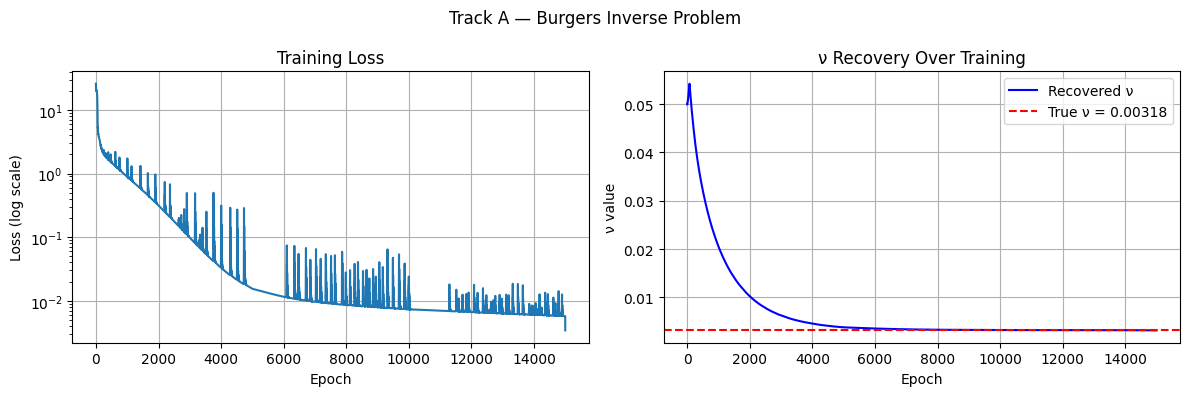

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (log scale)')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(nu_history, color='blue', label='Recovered ν')
ax2.axhline(y=nu_true, color='red', linestyle='--', label=f'True ν = {nu_true:.5f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ν value')
ax2.set_title('ν Recovery Over Training')
ax2.legend()
ax2.grid(True)

plt.suptitle('Track A — Burgers Inverse Problem')
plt.tight_layout()
plt.show()